In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import feather
import os
import seaborn as sns

In [4]:
# define the home directory (should contain pixel_output_dir from pixel clustering notebook)
base_dir = "../../../"

# explicitly set cell_cluster_prefix to override datetime default
cell_cluster_prefix = 'all'#"qc_filtered"

# define the base output cell folder
cell_output_dir = '%s_cell_output_dir' % cell_cluster_prefix
if not os.path.exists(os.path.join(base_dir, "pixie", cell_output_dir)):
    os.mkdir(os.path.join(base_dir, "pixie", cell_output_dir))
    
# define the paths to cell clustering files, explicitly set the variables to use custom names
cell_som_weights_name = os.path.join("pixie", cell_output_dir, 'cell_som_weights.feather')
cluster_counts_name = os.path.join("pixie", cell_output_dir, 'cluster_counts.feather')
cluster_counts_size_norm_name = os.path.join("pixie", cell_output_dir, 'cluster_counts_size_norm.feather')
weighted_cell_channel_name = os.path.join("pixie", cell_output_dir, 'weighted_cell_channel.feather')
cell_som_cluster_count_avg_name = os.path.join("pixie", cell_output_dir, 'cell_som_cluster_count_avg.csv')
cell_meta_cluster_count_avg_name = os.path.join("pixie", cell_output_dir, 'cell_meta_cluster_count_avg.csv')
cell_som_cluster_channel_avg_name = os.path.join("pixie", cell_output_dir, 'cell_som_cluster_channel_avg.csv')
cell_meta_cluster_channel_avg_name = os.path.join("pixie", cell_output_dir, 'cell_meta_cluster_channel_avg.csv')
cell_meta_cluster_remap_name = os.path.join("pixie", cell_output_dir, 'cell_meta_cluster_mapping.csv')


In [5]:
pixel_cluster_prefix = "adj"
# define the output directory using the specified pixel cluster prefix
pixel_output_dir = os.path.join("pixie", "%s_pixel_output_dir" % pixel_cluster_prefix)
if not os.path.exists(os.path.join(base_dir, pixel_output_dir)):
    os.makedirs(os.path.join(base_dir, pixel_output_dir))

pixel_som_weights_name = os.path.join(pixel_output_dir, 'pixel_som_weights.feather')
pc_chan_avg_som_cluster_name = os.path.join(pixel_output_dir, 'pixel_channel_avg_som_cluster.csv')
pc_chan_avg_meta_cluster_name = os.path.join(pixel_output_dir, 'pixel_channel_avg_meta_cluster.csv')
pixel_meta_cluster_remap_name = os.path.join(pixel_output_dir, 'pixel_meta_cluster_mapping.csv')
#cell_table = pd.read_csv(os.path.join(base_dir,'segmentation','cell_table_contrast_adj','cell_table_size_normalized.csv'))

In [207]:
#pd.read_csv(os.path.join(base_dir, pc_chan_avg_som_cluster_name))
os.path.join(base_dir, pc_chan_avg_som_cluster_name)
!ls ../../../pixie/


adj_cell_output_dir	    kclPb_pixel_output_dir
adj_pixel_output_dir	    kclPb_pixel_output_dir_COPY
all_cell_output_dir	    kcl_pixel_output_dir
all_cell_output_dir-DELETE  new_cell_output_dir
all_pixel_output_dir	    new_pixel_output_dir
kcl_cell_output_dir	    qc_filtered_cell_output_dir
kclPb_cell_output_dir	    qc_filtered_pixel_output_dir
kclPb_cell_output_dir_COPY


,Alpha-SMA,B7-H4 / Beta-Cat,CD107a,CD107a / Alpha-SMA,CD11b,CD11b / B7-H4,CD14,CD16,CD163,CD20,...,CD8a / FoxP3,E-Cad / Beta-Cat,E-Cad / CD366,FoxP3,Granzyme-B,HLA-DR,Pan-keratine,Tbet,Vim / Granz-B / Pan-k,Vimentin / CD366
cell_som_cluster,,,,,,,,,,,,,,,,,,,,,
1,0.001911,0.001067,0.000449,0.000018,0.005060,0.000298,0.002388,0.007304,0.001804,0.013002,...,0.000001,0.000017,0.000000e+00,0.003828,0.000084,0.005548,0.000002,0.000332,0.000000,0.000050
2,0.007667,0.006555,0.002026,0.000229,0.016227,0.001006,0.012656,0.039133,0.008774,0.031018,...,0.000019,0.000188,0.000000e+00,0.019339,0.000353,0.018964,0.000010,0.000924,0.000000,0.000238
3,0.035761,0.034353,0.008324,0.001146,0.100123,0.003133,0.062450,0.040117,0.019883,0.012053,...,0.000123,0.001588,6.764277e-07,0.014003,0.001110,0.015649,0.000085,0.002311,0.000000,0.001288
4,0.005445,0.004754,0.001333,0.000186,0.014622,0.000385,0.009817,0.026759,0.007240,0.027100,...,0.000100,0.000212,0.000000e+00,0.008036,0.000184,0.013366,0.000007,0.000316,0.000000,0.000183
5,0.004725,0.002834,0.001607,0.000074,0.005621,0.000974,0.005783,0.014880,0.005445,0.001077,...,0.000992,0.000036,0.000000e+00,0.003450,0.000148,0.006744,0.000009,0.000941,0.000000,0.000637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.026486,0.000070,0.004315,0.000323,0.001774,0.047855,0.031799,0.000658,0.004826,0.000986,...,0.000255,0.000014,2.042220e-04,0.006778,0.001981,0.001354,0.000204,0.317202,0.000015,0.474538
97,0.009798,0.000109,0.001083,0.000425,0.001147,0.021845,0.014150,0.000345,0.003868,0.000845,...,0.000871,0.000002,2.586006e-04,0.000807,0.001730,0.000477,0.000142,0.010856,0.000010,0.895049
98,0.050478,0.000889,0.006040,0.003889,0.009422,0.033284,0.107043,0.003716,0.020942,0.006155,...,0.003232,0.000083,1.600951e-03,0.007301,0.009035,0.005657,0.001918,0.017079,0.000149,0.542920


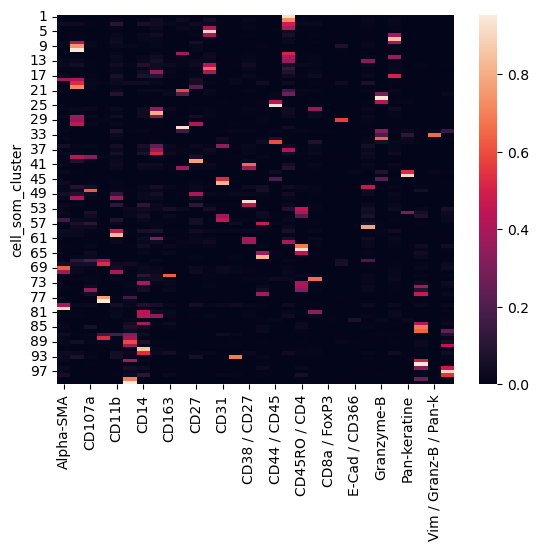

In [210]:
cell_som_cluster_count = pd.read_csv(os.path.join(base_dir, cell_som_cluster_count_avg_name)).set_index('cell_som_cluster').drop(['count','cell_meta_cluster','cell_meta_cluster_rename'],axis =1)
cell_som_cluster_count.columns = cell_som_cluster_count.columns.str.replace('pixel_meta_cluster_rename_','')
sns.heatmap(cell_som_cluster_count)
cell_som_cluster_count

In [223]:
!ls ../../../segmentation/dee

cell_table		 deepcell_input_contrast_adj   deepcell_output_Denoised
cell_table_contrast_adj  deepcell_input_Denoised       deepcell_visualization
cell_table_Denoised	 deepcell_output	       LeapID_segmented.csv
deepcell_input		 deepcell_output_contrast_adj


In [224]:
#number of clusters in a cell
cluster_counts = feather.read_dataframe(os.path.join(base_dir, cluster_counts_name))
cluster_counts_norm = feather.read_dataframe(os.path.join(base_dir, cluster_counts_size_norm_name))

In [176]:
a = (cluster_counts.iloc[:,3:].div(cluster_counts.cell_size,axis=0)>1)
cluster_counts[a.any(axis = 1)]

,cell_size,fov,label,pixel_meta_cluster_rename_Alpha*,pixel_meta_cluster_rename_Alpha-SMA,pixel_meta_cluster_rename_B7H4-ECad/PanCk***,pixel_meta_cluster_rename_B7H4-PanCK,pixel_meta_cluster_rename_CD107a,pixel_meta_cluster_rename_CD11b-GanzB-CD45,pixel_meta_cluster_rename_CD14,...,pixel_meta_cluster_rename_CD8a-FoxP3,pixel_meta_cluster_rename_ECad-FOXP3-BetaCat,pixel_meta_cluster_rename_ECad/Beta/PanCK,pixel_meta_cluster_rename_ECad/Beta/PanCK-B7H4,pixel_meta_cluster_rename_FoxP3*,pixel_meta_cluster_rename_HLA,pixel_meta_cluster_rename_HLA-CD68,pixel_meta_cluster_rename_PanCK-ECad,pixel_meta_cluster_rename_T-bet,pixel_meta_cluster_rename_Vimentin
16,29.0,Leap001_10,17,0.0,0.0,19.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,31.0,0.0,0.0,5.0,0.0,0.0
41,30.0,Leap001_10,42,0.0,0.0,43.0,14.0,0.0,0.0,0.0,...,0.0,0.0,12.0,0.0,9.0,0.0,0.0,11.0,0.0,0.0
57,51.0,Leap001_10,58,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,47.0,Leap001_10,61,0.0,0.0,11.0,7.0,0.0,0.0,0.0,...,0.0,0.0,8.0,0.0,2.0,0.0,0.0,3.0,0.0,0.0
62,27.0,Leap001_10,63,13.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191914,24.0,Leap008_7,5819,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
191915,29.0,Leap008_7,5820,0.0,0.0,10.0,4.0,0.0,0.0,0.0,...,0.0,1.0,15.0,5.0,0.0,0.0,0.0,67.0,0.0,0.0
191916,59.0,Leap008_7,5821,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
191917,6.0,Leap008_7,5822,0.0,0.0,57.0,0.0,0.0,0.0,0.0,...,0.0,0.0,21.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0


In [220]:
a = pd.concat((cluster_counts.iloc[:,3:].sum(axis = 1).rename('sum'),cluster_counts.cell_size),axis = 1)
(a['sum']==a.cell_size).sum(),len(a.cell_size)


(3688356, 3962620)

In [192]:
pixel_cluster_col = 'pixel_meta_cluster'
fov_pixel_data = feather.read_dataframe(
            os.path.join(base_dir,pixel_data_dir, 'Leap001_10' + '.feather')
        )
fov_pixel_data
group_by_cluster_col = fov_pixel_data.groupby(
    ['label', pixel_cluster_col]
).size().reset_index(name='count')

# if cluster labels end up as float (can happen with numeric types), convert to int
if group_by_cluster_col[pixel_cluster_col].dtype == float:
    group_by_cluster_col[pixel_cluster_col] = group_by_cluster_col[
        pixel_cluster_col
    ].astype(int)

# counts number of pixel SOM/meta clusters per cell
num_cluster_per_seg_label = group_by_cluster_col.pivot(
    index='label', columns=pixel_cluster_col, values='count'
).fillna(0).astype(int)
num_cluster_per_seg_label.sum(axis = 1)

label
0       26902
1          19
2          22
3          37
4          13
        ...  
3181       27
3182       10
3183       29
3184       13
3185       15
Length: 3186, dtype: int64

In [194]:
cluster_counts[['cell_size','label']]

,cell_size,label
0,20.0,1
1,23.0,2
2,28.0,3
3,18.0,4
4,22.0,5
...,...,...
3589071,32.0,12942
3589072,27.0,12943
3589073,39.0,12944
3589074,39.0,12945


In [131]:
cluster_counts.iloc[cluster_counts.iloc[:,3].argmax()]

cell_size                                                         3.0
fov                                                       Leap005_2_5
label                                                             731
pixel_meta_cluster_rename_Alpha*                            20.833333
pixel_meta_cluster_rename_Alpha-SMA                          0.385346
pixel_meta_cluster_rename_B7H4-ECad/PanCk***                 0.575331
pixel_meta_cluster_rename_B7H4-PanCK                              0.0
pixel_meta_cluster_rename_CD107a                                  0.0
pixel_meta_cluster_rename_CD11b-GanzB-CD45                        0.0
pixel_meta_cluster_rename_CD14                                    0.0
pixel_meta_cluster_rename_CD16-CD14                          0.658879
pixel_meta_cluster_rename_CD163                                   0.0
pixel_meta_cluster_rename_CD20                                    0.0
pixel_meta_cluster_rename_CD27                                    0.0
pixel_meta_cluster_r

(0.0, 100.0)

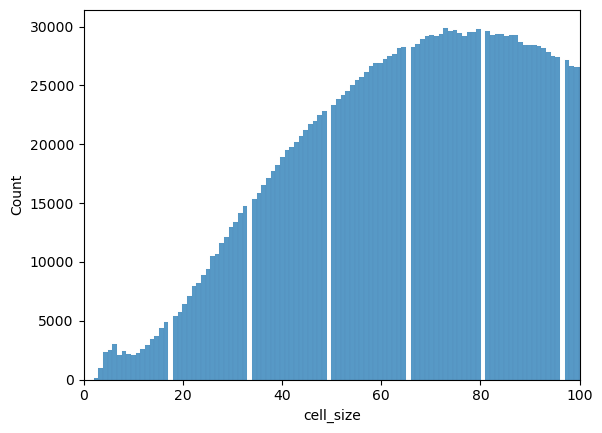

In [144]:
sns.histplot(cluster_counts.cell_size)
plt.xlim(0,100)
#plt.semilogy()

In [142]:
cluster_counts[cluster_counts.cell_size>10].max()

cell_size                                                     2822.0
fov                                                        Leap105_9
label                                                          19323
pixel_meta_cluster_rename_Alpha*                           12.103175
pixel_meta_cluster_rename_Alpha-SMA                         6.831134
pixel_meta_cluster_rename_B7H4-ECad/PanCk***                5.111597
pixel_meta_cluster_rename_B7H4-PanCK                        7.552632
pixel_meta_cluster_rename_CD107a                              5.1875
pixel_meta_cluster_rename_CD11b-GanzB-CD45                  6.857465
pixel_meta_cluster_rename_CD14                              2.076923
pixel_meta_cluster_rename_CD16-CD14                         8.760092
pixel_meta_cluster_rename_CD163                             3.960057
pixel_meta_cluster_rename_CD20                              5.692308
pixel_meta_cluster_rename_CD27                              1.710526
pixel_meta_cluster_rename_CD3     

[]

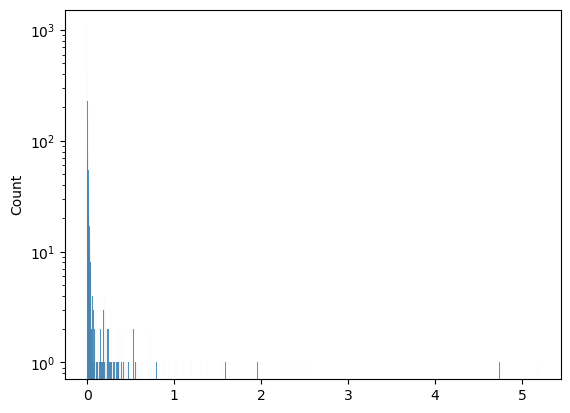

In [77]:
sns.histplot(cell_som_cluster_count.values.reshape(-1))
plt.semilogy()

In [14]:
cell_cl = pd.read_csv(os.path.join(base_dir, cell_som_cluster_channel_avg_name))
cell_cl = cell_cl.sort_values(by = 'cell_meta_cluster_rename').drop('cell_meta_cluster',axis = 1)

In [62]:
cell_cl.drop('cell_meta_cluster_rename',axis = 1).set_index('cell_som_cluster').max(axis = 1).sort_values()

cell_som_cluster
49    0.296899
36    0.334273
18    0.335869
5     0.338773
30    0.339143
        ...   
93    2.592309
96    3.003064
78    3.364978
91    8.896088
6     9.188481
Length: 100, dtype: float64

<Axes: ylabel='cell_som_cluster'>

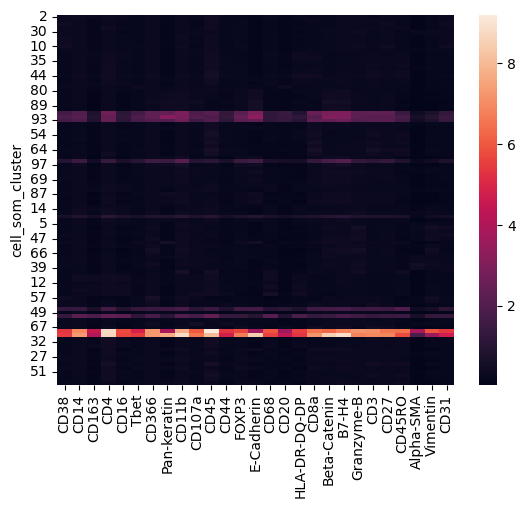

In [50]:
sns.heatmap(cell_cl.drop('cell_meta_cluster_rename',axis = 1).set_index('cell_som_cluster'))

<Axes: ylabel='cell_meta_cluster_rename'>

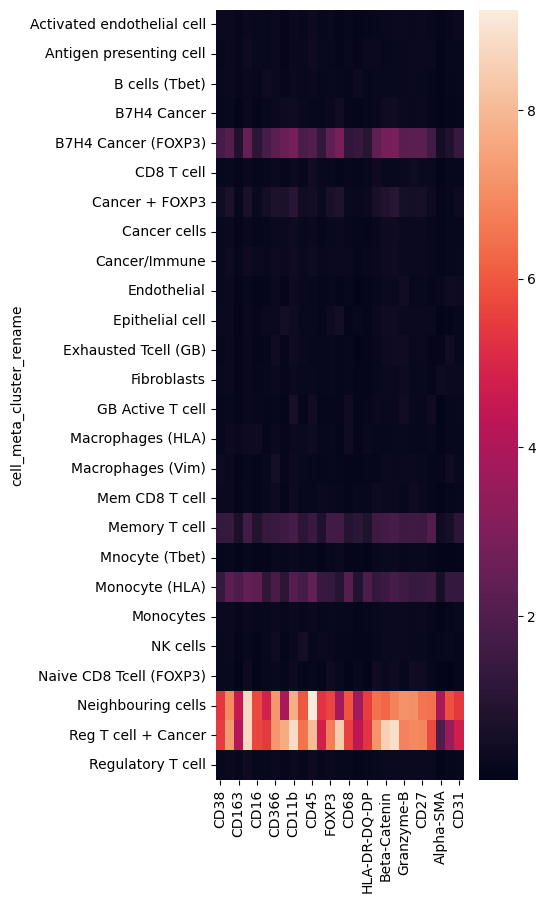

In [22]:
plt.figure(figsize = (4,10))
sns.heatmap(cell_cl.set_index('cell_som_cluster').groupby('cell_meta_cluster_rename').mean())

In [87]:
cell_cl['cell_meta_cluster_rename']=='Reg T cell + Cancer'

1     False
28    False
19    False
18    False
29    False
      ...  
93    False
50    False
51    False
60    False
84    False
Name: cell_meta_cluster_rename, Length: 100, dtype: bool

<Axes: ylabel='cell_meta_cluster_rename-cell_som_cluster'>

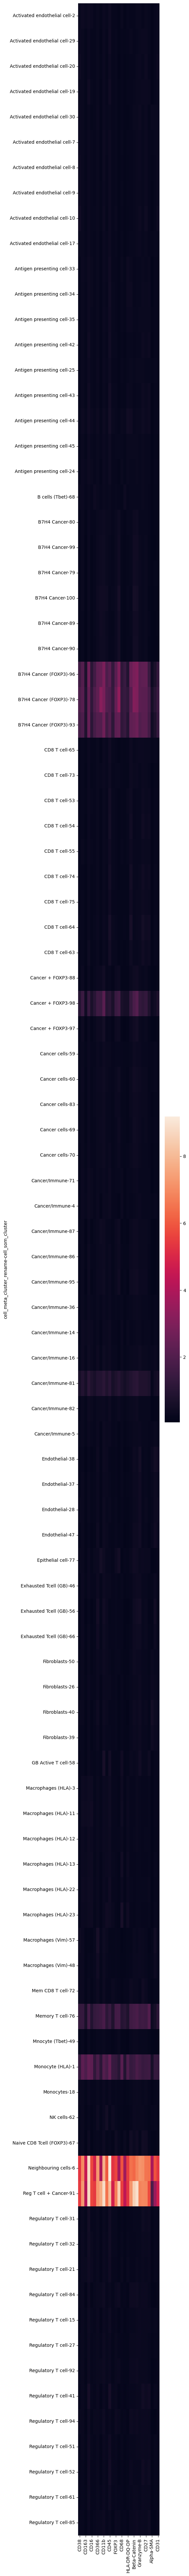

In [39]:
plt.figure(figsize = (4,100))
a = cell_cl.set_index(['cell_meta_cluster_rename','cell_som_cluster'])
sns.heatmap(a)

In [7]:
file_name = 'data/sc_protein_contrast_adj.h5ad'
adata = sc.read_h5ad(file_name)

In [10]:
adata.obs.acquisition_ID.value_counts()

acquisition_ID
Leap042_6     19500
Leap086_5     13346
Leap088a_1    12814
Leap043_6     12759
Leap086_6     12423
              ...  
Leap010_9      1158
Leap003_16     1158
Leap057_2      1137
Leap008_8      1128
Leap011_2      1085
Name: count, Length: 577, dtype: int64